In [1]:
import numpy as np
from numpy.linalg import inv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.covariance import graphical_lasso, GraphicalLasso, GraphicalLassoCV
from tqdm.notebook import tqdm

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import scipy.cluster.hierarchy as sch

In [2]:
# read HJ Andrews Data
df = pd.read_csv('../../data/hj_andrews_clean.csv')
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
df = df.set_index('DATE_TIME')
df.head()

,PA002,PA003,PA004,PA005,PA006,PA009,PA010,PA011,PA012,PA013,...,PB331,PB332,PB333,PB335,PB337,PB343,PB346,PB356,PB357,PB358
DATE_TIME,,,,,,,,,,,,,,,,,,,,,
2011-05-01 01:00:00,0.2,0.6,0.9,0.2,0.9,0.5,0.7,0.5,0.6,-0.3,...,-1.1,-1.3,-1.3,-0.3,0.7,0.8,0.4,0.7,0.2,-2.7
2011-05-01 02:00:00,-0.1,0.4,0.6,-0.1,0.7,0.2,0.4,0.3,0.3,-0.5,...,-1.3,-1.4,-1.5,-0.7,0.7,0.4,0.1,0.4,-0.1,-3.0
2011-05-01 03:00:00,-0.3,0.3,0.5,-0.2,0.5,0.1,0.3,0.3,0.3,-0.6,...,-1.4,-1.6,-1.6,-1.0,0.4,0.4,0.0,0.3,-0.1,-3.3
2011-05-01 04:00:00,-0.4,0.1,0.2,-0.3,0.3,-0.1,0.2,0.2,0.1,-0.8,...,-1.7,-1.8,-1.7,-1.2,-0.2,0.1,-0.2,0.2,-0.3,-3.5
2011-05-01 05:00:00,-0.5,0.1,0.1,-0.6,0.4,-0.1,-0.1,0.1,-0.1,-0.8,...,-1.9,-2.1,-2.1,-1.3,-0.4,0.0,-0.1,0.0,-0.5,-3.8


In [3]:
latlong = pd.read_csv("../../data/HJA_xy_coord_elv_bird_pts.csv")
latlong.head()

,Plot,PlotNum,X,Y,Elv (m)
0,2,2,563755,4897830,603.23
1,3,3,563755,4897530,648.59
2,4,4,563755,4897230,766.32
3,5,5,563755,4896630,912.25
4,6,6,563755,4896330,993.51


In [4]:
latlong.tail()

,Plot,PlotNum,X,Y,Elv (m)
180,PC14,514,567112,4900997,964.51
181,PC15,515,566230,4901776,970.79
182,PC16,516,565617,4901912,1030.05
183,PC17,517,568874,4902589,1301.42
184,PC18,518,569010,4902722,1338.87


In [5]:
# remove sensors I don't know the label for
latlong_df = latlong[~latlong['Plot'].str.contains("PC")]
latlong_df.tail()

,Plot,PlotNum,X,Y,Elv (m)
162,354,354,561686,4895983,843.02
163,356,356,562384,4895868,885.60
164,357,357,562681,4895810,873.27
165,358,358,570678,4895092,1310.27
166,400,400,567657,4895416,1055.28


In [6]:
# trim labels and remove non-overlapping sensors between two files
df_nums = [x[2:] for x in list(df.columns)]
latlong_df["Plot"] = [str(x.zfill(3)) for x in latlong_df["Plot"].values]
print(set(df_nums) - set(latlong_df["Plot"]))
df_copy = df.copy()
df_copy.columns = df_nums
df_copy = df_copy.loc[:, df_copy.columns != '506']
df_copy.shape

{'506'}


/tmp/ipykernel_25436/620129347.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latlong_df["Plot"] = [str(x.zfill(3)) for x in latlong_df["Plot"].values]


(28487, 167)

In [7]:
df_copy_sorted = df_copy.sort_index(axis=1)
df_copy_sorted.head()

,002,003,004,005,006,008,009,010,011,012,...,349,350,351,352,353,354,356,357,358,400
DATE_TIME,,,,,,,,,,,,,,,,,,,,,
2011-05-01 01:00:00,0.2,0.6,0.9,0.2,0.9,-0.4,0.5,0.7,0.5,0.6,...,-0.3,0.3,0.7,-0.1,0.7,1.0,0.7,0.2,-2.7,0.0
2011-05-01 02:00:00,-0.1,0.4,0.6,-0.1,0.7,-0.7,0.2,0.4,0.3,0.3,...,-0.6,0.3,0.3,-0.6,0.5,0.7,0.4,-0.1,-3.0,-0.3
2011-05-01 03:00:00,-0.3,0.3,0.5,-0.2,0.5,-0.9,0.1,0.3,0.3,0.3,...,-0.8,0.0,0.3,-1.1,0.2,0.4,0.3,-0.1,-3.3,-0.3
2011-05-01 04:00:00,-0.4,0.1,0.2,-0.3,0.3,-1.1,-0.1,0.2,0.2,0.1,...,-1.0,-0.6,0.1,-1.3,-0.1,0.1,0.2,-0.3,-3.5,-0.6
2011-05-01 05:00:00,-0.5,0.1,0.1,-0.6,0.4,-1.3,-0.1,-0.1,0.1,-0.1,...,-1.1,-0.7,0.0,-1.5,-0.3,-0.1,0.0,-0.5,-3.8,-0.6


In [8]:
# downsample to noon each day
# only initially for the sake of memory/computation
noon_df = df_copy_sorted[df_copy_sorted.index.hour == 12]
noon_df = noon_df.resample('d').mean()
noon_df.index.freq = 'd'
noon_df.head()

,002,003,004,005,006,008,009,010,011,012,...,349,350,351,352,353,354,356,357,358,400
DATE_TIME,,,,,,,,,,,,,,,,,,,,,
2011-05-01,11.1,10.5,9.8,5.8,5.9,13.4,10.9,6.1,7.2,8.0,...,13.2,9.3,8.2,14.5,7.4,7.8,8.1,5.7,15.9,8.4
2011-05-02,4.7,4.4,4.2,2.9,2.2,5.3,4.5,3.3,3.6,3.3,...,5.3,5.3,3.4,6.3,3.9,4.3,3.4,2.9,1.5,1.4
2011-05-03,8.9,8.2,7.8,5.7,5.1,10.1,8.5,6.0,7.2,7.3,...,10.0,7.6,7.4,11.8,7.7,8.2,7.4,5.6,8.7,5.3
2011-05-04,15.1,14.1,14.3,9.9,8.3,17.2,14.8,10.1,12.1,13.3,...,16.9,13.5,13.5,18.0,11.7,12.2,13.4,9.7,19.3,11.7
2011-05-05,11.8,11.4,11.5,7.9,6.3,12.7,11.8,8.2,10.1,9.8,...,12.5,11.5,9.9,11.9,9.8,10.3,9.9,7.8,9.7,7.5


In [9]:
noon_df.shape

(1187, 167)

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.structural import UnobservedComponents as UCM
from statsmodels.tsa.seasonal import STL

"""
Decompose the data using STL

Save the seasonal, trend, and residual into separate dataframes
We will work with the residuals

This step is by far the most expensive empirically I've noticed,
as we're decomposing 167 individual time series (one per sensor/channel)
"""
seasonal_df = pd.DataFrame()
trend_df = pd.DataFrame()
resid_df = pd.DataFrame()
for i in tqdm(range(noon_df.shape[1])):
    model = STL(noon_df.values[:, i], period=365)
    result = model.fit()
    seasonal_df[noon_df.columns[i]] = result.seasonal
    trend_df[noon_df.columns[i]] = result.trend
    resid_df[noon_df.columns[i]] = result.resid
seasonal_df.index = noon_df.index
trend_df.index = noon_df.index
resid_df.index = noon_df.index

  0%|          | 0/167 [00:00<?, ?it/s]

/tmp/ipykernel_25436/2479798701.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  seasonal_df[noon_df.columns[i]] = result.seasonal
/tmp/ipykernel_25436/2479798701.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  trend_df[noon_df.columns[i]] = result.trend
/tmp/ipykernel_25436/2479798701.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de

In [11]:
trend_df.to_csv("/nfs/hpc/share/dinkinst/data/hj_andrews_trend_noon.csv")
seasonal_df.to_csv("/nfs/hpc/share/dinkinst/data/hj_andrews_seasonal_noon.csv")
resid_df.to_csv("/nfs/hpc/share/dinkinst/data/hj_andrews_residuals_noon.csv")

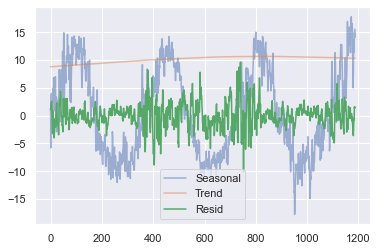

In [12]:
plt.plot(seasonal_df.values[:, 0], label='Seasonal', alpha=0.5)
plt.plot(trend_df.values[:, 0], label='Trend', alpha=0.5)
plt.plot(resid_df.values[:, 0], label='Resid')
plt.legend()

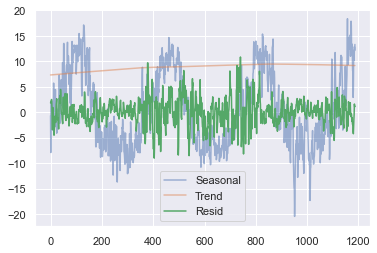

In [13]:
plt.plot(seasonal_df.values[:, -1], label='Seasonal', alpha=0.5)
plt.plot(trend_df.values[:, -1], label='Trend', alpha=0.5)
plt.plot(resid_df.values[:, -1], label='Resid')
plt.legend()

In [14]:
from sklearn import covariance, preprocessing

# scale residuals to mean 0 variance of 1
scaler = preprocessing.StandardScaler()
resid_scaled = scaler.fit_transform(resid_df.values)
resid_scaled

array([[ 0.46531334,  0.35331539,  0.51676253, ...,  0.20445209,
         1.27474844,  0.66279324],
       [ 0.73722209,  0.59903021,  0.83850967, ...,  0.68199305,
         0.62388375,  0.75249852],
       [ 0.98951624,  0.80642333,  0.94262062, ...,  0.79092768,
        -0.07228582,  0.80282119],
       ...,
       [ 0.69474781,  0.30721418,  0.62421908, ...,  0.48192437,
         0.34536937,  0.58932476],
       [ 0.57560598,  0.33372923,  0.47765567, ...,  0.47745069,
        -0.1717056 ,  0.38496794],
       [ 0.69648245,  0.30994984,  0.56573917, ...,  0.44824477,
         0.14174686,  0.42250632]])

In [15]:
# run graphical lasso on scaled residuals
# fairly quick using package
ret = GraphicalLasso(max_iter=1000, alpha=0.8, tol=1e-5).fit(resid_scaled)
ret

GraphicalLasso(alpha=0.8, max_iter=1000, tol=1e-05)

In [16]:
precision = ret.precision_.copy()
# edge weights are considered to be (in absolute value) indicative of a close "distance" between neighbors
# set max(abs(distance)) to be 0, everything else scaled relatively

# threshold with empirical choice of epsilon
precision[np.abs(precision) <= 0.01] = 0.0

# "distance hack" to ignore zeros in the precision matrix, when converting to distance matrix
precision[precision==-0.0] = 10.0
precision[precision==0.0] = 10.0
precision -= precision.min()
precision

array([[ 1.28479947,  0.05169573, 10.08093172, ...,  0.06546077,
        10.08093172, 10.08093172],
       [ 0.05169573,  1.25384531,  0.06961589, ...,  0.06458025,
        10.08093172, 10.08093172],
       [10.08093172,  0.06961589,  1.30725017, ..., 10.08093172,
        10.08093172, 10.08093172],
       ...,
       [ 0.06546077,  0.06458025, 10.08093172, ...,  1.29382593,
        10.08093172, 10.08093172],
       [10.08093172, 10.08093172, 10.08093172, ..., 10.08093172,
         1.09627452, 10.08093172],
       [10.08093172, 10.08093172, 10.08093172, ..., 10.08093172,
        10.08093172,  1.30792313]])

<AxesSubplot:>

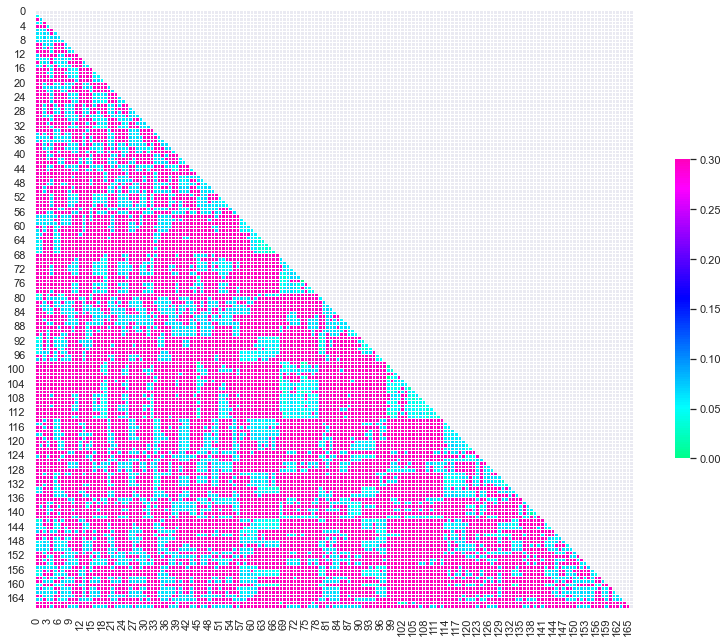

In [17]:
mask = np.triu(np.ones_like(precision, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(15, 11))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(precision, mask=mask, cmap='gist_rainbow', vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

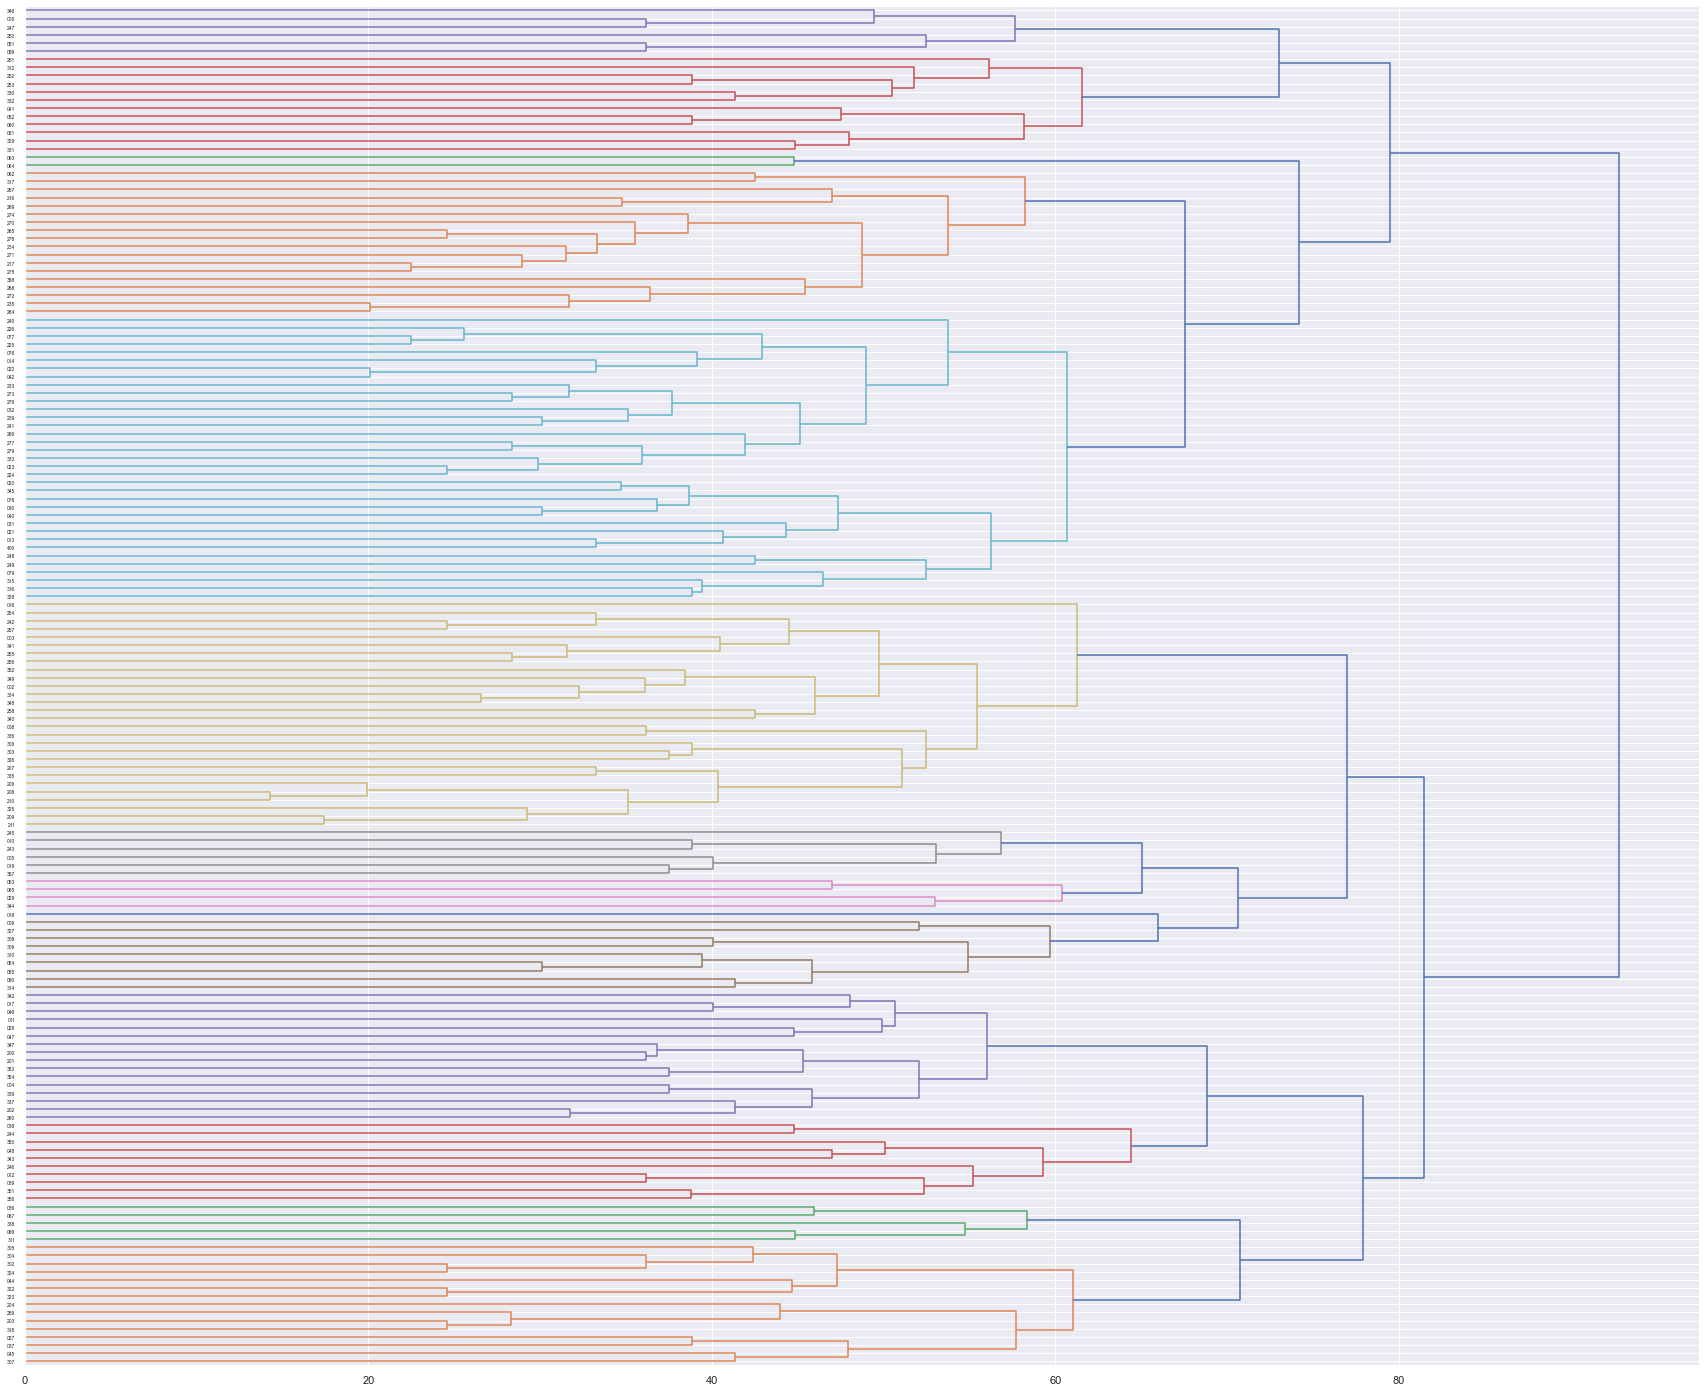

In [18]:
# convert precision matrix (now all positive values) to distance matrix
# "distance hack" makes 0's from GLasso prohibitively expensive to cluster together

pairwise_distances = sch.distance.pdist(precision)
Z = linkage(pairwise_distances,
            method='average'  # dissimilarity metric: max distance across all pairs of 
                               # records between two clusters
    )
# calculate full dendrogram and visualize it
plt.figure(figsize=(30, 25))
dendrogram(
            Z,
            orientation='right',
            labels=noon_df.columns,
            distance_sort='descending',
            show_leaf_counts=False
          )
plt.show()

In [19]:
# cut dendrogram at 4 clusters
cutree1 = hierarchy.cut_tree(Z, n_clusters=4).squeeze()
cutree1

array([0, 0, 1, 0, 2, 0, 0, 0, 1, 1, 3, 3, 0, 1, 0, 0, 3, 3, 3, 3, 1, 1,
       0, 3, 3, 3, 1, 1, 1, 1, 3, 2, 3, 1, 1, 1, 1, 1, 2, 2, 0, 0, 0, 2,
       2, 3, 3, 3, 0, 1, 1, 3, 3, 3, 3, 0, 2, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 1, 0, 1, 2, 3, 3, 2,
       2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 2, 0, 3, 3, 3, 1, 1, 1,
       1, 0, 0, 0, 3, 2, 2, 2, 2, 3, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 3,
       2, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 3, 3])

/tmp/ipykernel_25436/3143367495.py:7: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Cluster')


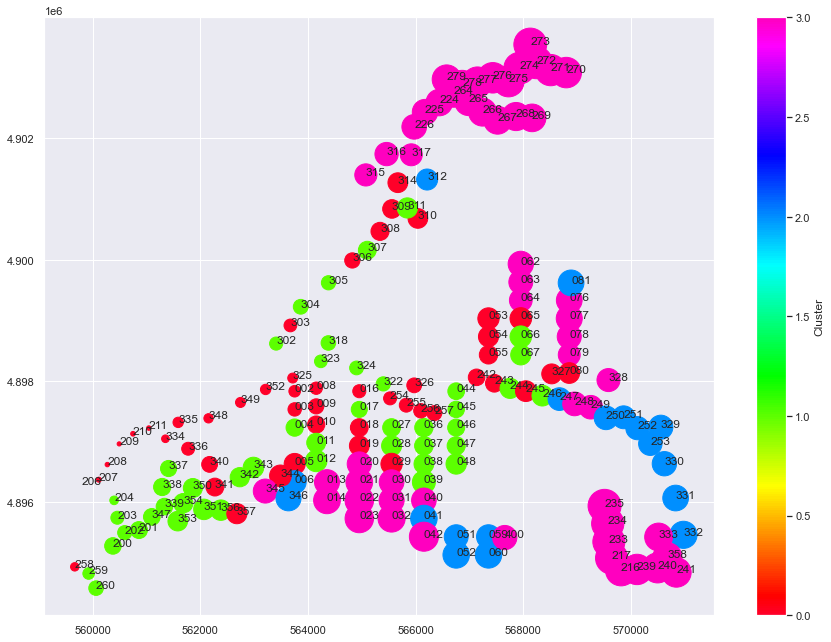

In [20]:
f, ax = plt.subplots(figsize=(15, 11))
plt.scatter(x=latlong_df['X'], 
            y=latlong_df['Y'], 
            c=cutree1, 
            cmap='gist_rainbow', 
            s=(latlong_df['Elv (m)']-latlong_df['Elv (m)'].min()))
plt.colorbar(label='Cluster')

for i, txt in enumerate(latlong_df['Plot']):
    plt.annotate(txt, (latlong_df['X'][i], latlong_df['Y'][i]))

In [21]:
"""
Create basis matrices
"""

prec = ret.precision_
basis_matrices = []
for i in range(max(set(cutree1))+1): # iterate over clusters
    idxs = np.where(cutree1 == i)[0] # indexes for given cluster
    A = np.zeros(prec.shape) # blank A matrix
    for idx in idxs: # loop over indexes
        for idx2 in idxs: # loop over indexes
            A[idx][idx2] = prec[idx][idx2] # set i,j entry to be the entry from precision matrix for given cluster
    basis_matrices.append(A)
basis_matrices = np.array(basis_matrices)

In [22]:
"""
Ensure precision matrix from basis matrices summation is symmetric/pos_def
"""
def is_pos_def(A):
    if np.allclose(A, A.T):
        try:
            np.linalg.cholesky(A)
            return True
        except np.linalg.LinAlgError:
            return False
    else:
        return False
def is_symmetric(a, rtol=1e-05, atol=1e-08):
    return np.allclose(a, a.T, rtol=rtol, atol=atol)
    
is_pos_def(basis_matrices.sum(axis=0)), is_symmetric(basis_matrices.sum(axis=0))

(True, True)

In [23]:
"""
Ensure each basis matrix is symmetric

Should all be linearly independent by design
I don't believe they need to be posdef, just the resulting sum(coeffs*basis_matrices)

Here, coeffs are assumed to be 1, by construction again
"""

for i in range(basis_matrices.shape[0]):
    print(is_symmetric(basis_matrices[i]))

True
True
True
True


In [24]:
"""
Anderson 1969/1970 functions for iterative solutions of coefficients

>Unbiased initialization of coefficients after GLasso may be a problem
>Sample covariance is NOT sparse, GLasso precision estimate is

>Unsure how to improve initialization tonight...
"""

def calc_matrices_precision(psi_hat, H_s, C, dim):
    A = np.zeros((dim, dim))
    B = np.zeros((dim,))
    inv_psi_hat = inv(psi_hat) # calculate psi_hat inverse
    for g in range(dim):
        for h in range(dim):
            mult = ((inv_psi_hat.dot(H_s[g])).dot(inv_psi_hat)).dot(H_s[h])
            lhs = np.trace(mult)
            A[g, h] = lhs
        rhs = np.trace(inv_psi_hat.dot(H_s[g])) - np.trace(C.dot(H_s[g]))
        B[g] = rhs
        
    return A, B

def iterative_soln_precision(coeffs_zero, H_s, C, dim, iters=5):
    s_imo = coeffs_zero
    for it in range(iters):
        psi_hat = (s_imo.reshape(-1, 1, 1)*H_s).sum(0) # calculate psi_hat
        A, B = calc_matrices_precision(psi_hat, H_s, C, dim)
        t_i = inv(A).dot(B)
        s_i = s_imo + t_i
        print(s_i)
        s_imo = s_i
        
    return s_imo

def unbiased_init_precision(C, H_s, N, dim):
    A = np.zeros((dim, dim))
    B = np.zeros((dim, ))
    for g in range(dim):
        for h in range(dim):
            A[g, h] = np.trace(H_s[g].dot(H_s[h]))
        B[g] = np.trace(inv(C).dot(H_s[g]))
    return inv(A).dot(B)

def calc_likelihood_precision(coeffs, H_s, C, N, P):
    precision_hat = (coeffs.reshape(-1, 1, 1)*H_s).sum(0)
    log_l = -P*np.log(2*np.pi) + np.log(np.linalg.det(precision_hat)) - np.trace(np.dot(precision_hat, C))
    
    return log_l*(N/2)

In [25]:
# calculate sample covariance
C = np.cov(resid_scaled.T)
H_s = basis_matrices
M = H_s.shape[0] # number of clusters/basis matrices
N = resid_scaled.shape[0] # number of samples - assumed independent here after residuals/scaling
P = resid_scaled.shape[1]

In [26]:
# try random init, unbiased may have an issue with GLasso
np.random.seed(42)
s_zero = np.random.rand(M)
s_hat = iterative_soln_precision(s_zero, H_s, C, dim=M, iters=15)

[0.67407505 1.33095049 0.98095497 1.05230728]
[1.10520334 1.54384708 1.0944291  1.65656723]
[1.55730773 1.58334898 1.10907389 2.20279218]
[1.81790358 1.58438556 1.10927248 2.44228829]
[1.86880818 1.58438624 1.10927251 2.47115829]
[1.87027351 1.58438624 1.10927251 2.4715036 ]
[1.87027466 1.58438624 1.10927251 2.47150364]
[1.87027466 1.58438624 1.10927251 2.47150364]
[1.87027466 1.58438624 1.10927251 2.47150364]
[1.87027466 1.58438624 1.10927251 2.47150364]
[1.87027466 1.58438624 1.10927251 2.47150364]
[1.87027466 1.58438624 1.10927251 2.47150364]
[1.87027466 1.58438624 1.10927251 2.47150364]
[1.87027466 1.58438624 1.10927251 2.47150364]
[1.87027466 1.58438624 1.10927251 2.47150364]


In [27]:
calc_likelihood_precision(s_zero, H_s, C, N, P=P)

-251490.48550090074

In [28]:
calc_likelihood_precision(s_hat, H_s, C, N, P=P)

-203080.8897519845

In [29]:
calc_likelihood_precision(np.ones(M), H_s, C, N, P=P)

-220311.27792946846

In [30]:
# psihat using coeff estimates from Anderson
psi_hat = (s_hat.reshape(-1, 1, 1)*H_s).sum(0) # calculate psi_hat
psi_hat

array([[ 2.25156336, -0.05467934,  0.        , ..., -0.02893492,
         0.        ,  0.        ],
       [-0.05467934,  2.19367057,  0.        , ..., -0.03058174,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  1.94296207, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.02893492, -0.03058174,  0.        , ...,  2.26844531,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         2.50942344,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  3.03251375]])

In [31]:
"""
Check GLasso precision matrix

Portions will be "missing" due to thresholding step after GLasso, 
as well as clustering removing some of the edge connections in order to take only the most prominent

Keep in mind when comparing to psi_hat from Anderson + basis matrix construction/summation

We only used GLasso to construct the basis matrices for the precision matrix, and to induce sparsity

Sample precision matrix is likely not sparse, as data is very heavily correlated, even in scaled residuals
"""

prec

array([[ 1.20386775, -0.029236  , -0.00848196, ..., -0.01547095,
        -0.        , -0.        ],
       [-0.029236  ,  1.17291359, -0.01131583, ..., -0.01635147,
        -0.        , -0.        ],
       [-0.00848196, -0.01131583,  1.22631845, ..., -0.00871462,
        -0.        , -0.00870119],
       ...,
       [-0.01547095, -0.01635147, -0.00871462, ...,  1.21289421,
        -0.        , -0.00508279],
       [-0.        , -0.        , -0.        , ..., -0.        ,
         1.0153428 , -0.        ],
       [-0.        , -0.        , -0.00870119, ..., -0.00508279,
        -0.        ,  1.22699141]])

In [32]:
"""
THOUGHTS + STUFF
IGNORE IF IRRELEVANT (or whatever)


From here, probably need to check whether this coefficient estimation is sufficient. 

In practice, we'll be establishing some system "baseline" behavior by 
constructing the basis matrices in this manner. This assumes the sparsity behavior is consistent
in "normal operating conditions". Additionally, this assumes the basis matrices themselves represent a 
consistent and true decomposition of the sparse precision matrix in baseline conditions.

>Need to figure out how to select an appropriate, representative subset of the (supposed i.i.d.)
data in order perform the construction of basis matrices.

After constructing the basis matrix, I feel that the actual coeff estimation step is sound.
However, as mentioned, I don't know whether the sparsity assumptions are okay, although they
certainly make the computational burden lighter, as well as the CP localization (when it comes to that).

It's possible that GLasso may not be the right tool, and that some other form of cov/prec estimation
coupled with linkage clustering could prove more successful, but using the sample covariance out of the gate
does not produce nearly as meaningful clusters based on space/elevation on this dataset. 

I suspect we could also use GLasso simply to identify the clusters, then use some other tool for estimating the
actual precision matrix, though it would still be sparse due to the zeros outside of the connections
"within clusters". Perhaps worth thinking about a way to do this without the sparsity induction, and comparing
to just thresholding a sample cov/corr/prec matrix is probably worth doing at some point. Still need a 
way to performing the clustering however... 

Tony Cai for the zero entries (correlations that were previously 0, need to see if adding correlation
causes CP pre/post)
"""

'\nTHOUGHTS + STUFF\nIGNORE IF IRRELEVANT (or whatever)\n\n\nFrom here, probably need to check whether this coefficient estimation is sufficient. \n\nIn practice, we\'ll be establishing some system "baseline" behavior by \nconstructing the basis matrices in this manner. This assumes the sparsity behavior is consistent\nin "normal operating conditions". Additionally, this assumes the basis matrices themselves represent a \nconsistent and true decomposition of the sparse precision matrix in baseline conditions.\n\n>Need to figure out how to select an appropriate, representative subset of the (supposed i.i.d.)\ndata in order perform the construction of basis matrices.\n\nAfter constructing the basis matrix, I feel that the actual coeff estimation step is sound.\nHowever, as mentioned, I don\'t know whether the sparsity assumptions are okay, although they\ncertainly make the computational burden lighter, as well as the CP localization (when it comes to that).\n\nIt\'s possible that GLasso 

In [33]:
"""
>LIKELIHOOD RATIO TESTS GO HERE
"""

'\n>LIKELIHOOD RATIO TESTS GO HERE\n'